<a href="https://colab.research.google.com/github/AndrewUwU/EQ-Activiades-IARN/blob/main/AF8_RNC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Actividad 8: Redes Neuronales Convolucionales
## **Hora clase:** N4
**Nombres:**
* Andrés Esteban Eufraga Mejía _ 2021759
* Alondra Isabella Quintero Lucio _ 2049693
* Alan Tomás García García _ 2095422
* Jorge Elí Casas Cortés _  1993951
* Angel Aldair Villalpando Reyes _ 2010651

## Cargar librerías

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

## Cargar datos

In [6]:
(train_data, train_labels), (test_data, test_labels) = datasets.mnist.load_data()

## Preprocesamiento de datos

In [7]:
train_data = train_data / 255.0
test_data = test_data / 255.0

train_data = train_data.reshape((train_data.shape[0], 28, 28, 1))
test_data = test_data.reshape((test_data.shape[0], 28, 28, 1))

## Selección y entrenamiento del modelo

In [8]:
model = models.Sequential()

model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_data, train_labels, epochs=5, validation_data=(test_data, test_labels))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 52s 27ms/step - accuracy: 0.9545 - loss: 0.1470 - val_accuracy: 0.9833 - val_loss: 0.0470
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 50s 27ms/step - accuracy: 0.9850 - loss: 0.0474 - val_accuracy: 0.9889 - val_loss: 0.0345
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 50s 27ms/step - accuracy: 0.9897 - loss: 0.0325 - val_accuracy: 0.9891 - val_loss: 0.0373
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 50s 27ms/step - accuracy: 0.9923 - loss: 0.0248 - val_accuracy: 0.9918 - val_loss: 0.0238
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 26ms/step - accuracy: 0.9935 - loss: 0.0200 - val_accuracy: 0.9882 - val_loss: 0.0381


## Prueba del modelo

In [9]:
test_loss, test_acc = model.evaluate(test_data, test_labels, verbose=2)
print(f"\\nExactitud de predicción del modelo (Accuracy): {test_acc:.4f}")

313/313 - 4s - 12ms/step - accuracy: 0.9882 - loss: 0.0381
\nExactitud de predicción del modelo (Accuracy): 0.9882


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
\n--- 5 Predicciones de prueba ---
Imagen 0: Predicción del modelo = 7 | Valor Real = 7


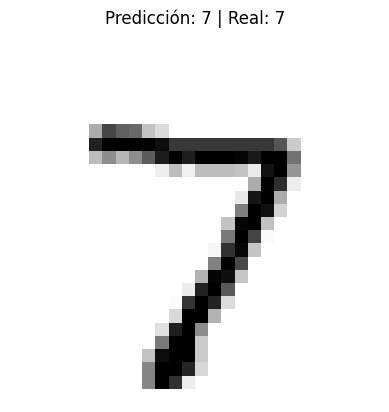

Imagen 1: Predicción del modelo = 2 | Valor Real = 2


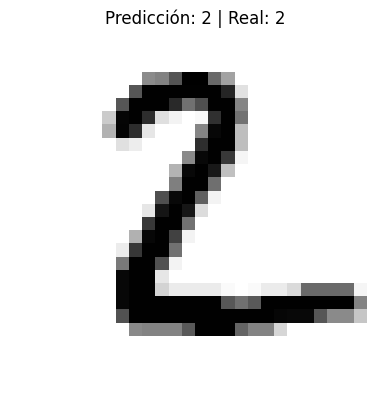

Imagen 2: Predicción del modelo = 1 | Valor Real = 1


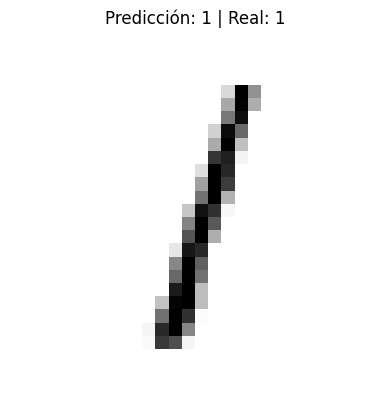

Imagen 3: Predicción del modelo = 0 | Valor Real = 0


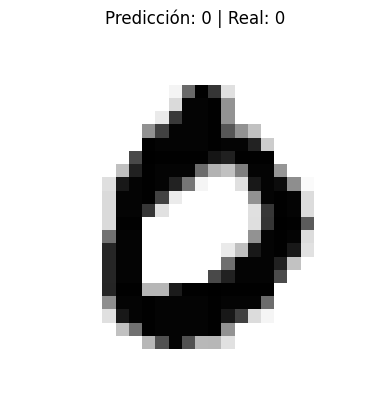

Imagen 4: Predicción del modelo = 4 | Valor Real = 4


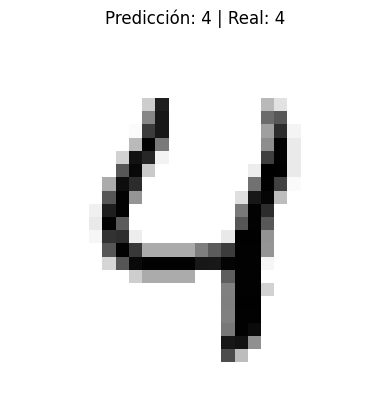

In [10]:
predictions = model.predict(test_data)

print("\\n--- 5 Predicciones de prueba ---")
for i in range(5):
    prediccion_actual = np.argmax(predictions[i])
    valor_real = test_labels[i]
    print(f"Imagen {i}: Predicción del modelo = {prediccion_actual} | Valor Real = {valor_real}")

    plt.imshow(test_data[i].reshape(28, 28), cmap=plt.cm.binary)
    plt.title(f"Predicción: {prediccion_actual} | Real: {valor_real}")
    plt.axis('off')
    plt.show()